<a href="https://colab.research.google.com/github/Mick146/Mick146/blob/main/NLP1stApril2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**Tokeinzation**
It means breaking a large piece of text into smaller piece called tokens

**Types of Tokenization**
* Sentence Tokenization - splits the text into sentences
* Word Tokenization
* Character Tokenization
* SubWord Tokenization

**Sentence Tokenization**

In [ ]:
import nltk

In [ ]:
nltk.download('punkt_tab') # Rule Book for NLTK to perform NLP steps

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [ ]:
# .? !
from nltk.tokenize import sent_tokenize, word_tokenize

In [ ]:
text = "Hello! How are you doing? I am Learning NLP. It's really amazing. Dr. Aryan went to New York"
sentences = sent_tokenize(text)
print(sentences)

['Hello!', 'How are you doing?', 'I am Learning NLP.', "It's really amazing.", 'Dr. Aryan went to New York']


**SpaCy**

In [ ]:
import spacy

In [ ]:
nlp = spacy.load("en_core_web_sm") # It is a model

In [ ]:
doc = nlp(text)
for i, sent in enumerate(doc.sents,1):
  print(f'Sentence {i}: {sent.text}')

Sentence 1: Hello!
Sentence 2: How are you doing?
Sentence 3: I am Learning NLP.
Sentence 4: It's really amazing.
Sentence 5: Dr. Aryan went to New York


**Word Tokenization**

In [ ]:
text = "Hello! How are you doing? I am Learning NLP. It's really amazing."
words = word_tokenize(text)
print(words)

['Hello', '!', 'How', 'are', 'you', 'doing', '?', 'I', 'am', 'Learning', 'NLP', '.', 'It', "'s", 'really', 'amazing', '.']


In [ ]:
doc = nlp(text)
words_spacy = [token.text for token in doc]
words_spacy

['Hello',
 '!',
 'How',
 'are',
 'you',
 'doing',
 '?',
 'I',
 'am',
 'Learning',
 'NLP',
 '.',
 'It',
 "'s",
 'really',
 'amazing',
 '.']

**Character Level Tokenization**

In [ ]:
text = "Hello World!"
chat_tokens = list(text)

In [ ]:
chat_tokens

['H', 'e', 'l', 'l', 'o', ' ', 'W', 'o', 'r', 'l', 'd', '!']

##**Stemming**
Stemming is the process of reducing a word to its Root Form. It chops off the ending of words using simple rule

In [ ]:
from nltk.stem import PorterStemmer, SnowballStemmer, LancasterStemmer

In [ ]:
words = [
    'running','runner','ran',
    'easily','fairly', 'fairness',
    'studies','studying','studied',
    'happiness', 'happily','happy',
    'connected', 'connection', 'connecting'
]

In [ ]:
porter = PorterStemmer()
for word in words:
  print(f'{word}: {porter.stem(word)}')

running: run
runner: runner
ran: ran
easily: easili
fairly: fairli
fairness: fair
studies: studi
studying: studi
studied: studi
happiness: happi
happily: happili
happy: happi
connected: connect
connection: connect
connecting: connect


In [ ]:
snowball = SnowballStemmer('english') # We need to specify language
for word in words:
  print(f'{word}: {snowball.stem(word)}')

running: run
runner: runner
ran: ran
easily: easili
fairly: fair
fairness: fair
studies: studi
studying: studi
studied: studi
happiness: happi
happily: happili
happy: happi
connected: connect
connection: connect
connecting: connect


In [ ]:
lancaster = LancasterStemmer() # No need to pass language
for word in words:
  print(f'{word}: {lancaster.stem(word)}')

running: run
runner: run
ran: ran
easily: easy
fairly: fair
fairness: fair
studies: study
studying: study
studied: study
happiness: happy
happily: happy
happy: happy
connected: connect
connection: connect
connecting: connect


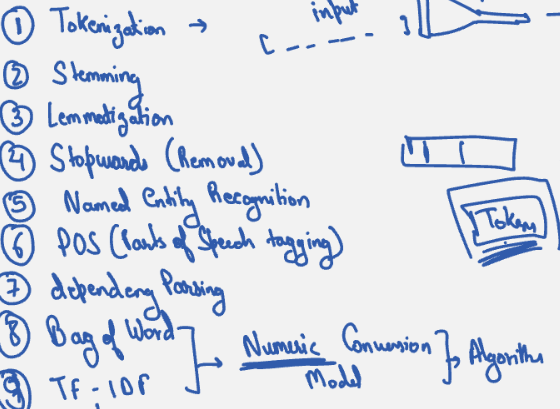

**Summary of Day 1:**

`tokenization -> break text into smaller chunks
stemming -> separate root words and suffixes
lemmatization -> classify words into noun/verb.. grammar work`

###**Lemmatization**
It reduces a word to its base dictionary form that we call as Lemma. Unlike stemming, it always produce a real, valud english word

**SpaCy**

In [ ]:
text = 'The children were happily running in the gardens with their dogs'
doc = nlp(text)

In [ ]:
for token in doc:
  print(f'{token.text:<15}{token.lemma_:<15}{token.pos_:<15} {spacy.explain(token.pos_)}')

The            the            DET             determiner
children       child          NOUN            noun
were           be             AUX             auxiliary
happily        happily        ADV             adverb
running        run            VERB            verb
in             in             ADP             adposition
the            the            DET             determiner
gardens        garden         NOUN            noun
with           with           ADP             adposition
their          their          PRON            pronoun
dogs           dog            NOUN            noun


**NLTK**

In [ ]:
nltk.download('wordnet') # It is a dictionary for lemmatization

[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

**Without POS Tagging**

In [ ]:
lemmatizer = WordNetLemmatizer()
test_words = ['running','better','studies','geese','was','happily']
for word in test_words:
  result = lemmatizer.lemmatize(word)
  print(f'{word:<15} -> {result:<15}')

running         -> running        
better          -> better         
studies         -> study          
geese           -> goose          
was             -> wa             
happily         -> happily        


**With POS**

In [ ]:
word_pos_pair = [('running','v'),('better','a'),('studies','n'),('geese','n'),('was','v'),('happily','r')]

for word,pos in word_pos_pair:
  result = lemmatizer.lemmatize(word,pos = pos)
  pos_name = {'n': 'noun', 'v':'verb','a':'adj','r':'adverb'}[pos]
  print(f'{word:>15} (as {pos_name:<8}) -> {result:<15}')

        running (as verb    ) -> run            
         better (as adj     ) -> good           
        studies (as noun    ) -> study          
          geese (as noun    ) -> goose          
            was (as verb    ) -> be             
        happily (as adverb  ) -> happily        


**Stopwords**

Stopwrodsa re the most common words in a language that carry very little meaning**

like: the, is,at, a

In [ ]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
from nltk.corpus import stopwords
stop_words_nltk = set(stopwords.words('english'))
stop_words_nltk

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [ ]:
# lowercase, tokenize, filter the stopwords
text = "This is a nice place and it can be very peaceful"

words = word_tokenize(text.lower())
filtered = [w for w in words if w not in stop_words_nltk]
filtered

['nice', 'place', 'peaceful']

**SpaCy**

In [ ]:
doc = nlp(text)
for token in doc:
  print(f'{token.text:<10} {token.is_stop}')

This       True
is         True
a          True
nice       False
place      False
and        True
it         True
can        True
be         True
very       True
peaceful   False


In [ ]:
stopwords.fileids() # langages supported to get stopwords

['albanian',
 'arabic',
 'azerbaijani',
 'basque',
 'belarusian',
 'bengali',
 'catalan',
 'chinese',
 'danish',
 'dutch',
 'english',
 'finnish',
 'french',
 'german',
 'greek',
 'hebrew',
 'hinglish',
 'hungarian',
 'indonesian',
 'italian',
 'kazakh',
 'nepali',
 'norwegian',
 'portuguese',
 'romanian',
 'russian',
 'slovene',
 'spanish',
 'swedish',
 'tajik',
 'tamil',
 'turkish',
 'uzbek']

###**NER (Named Entity Recognition)**
NER identifies and classifies real world entities in the text into categories:
- PERSON
- ORG
- GPE
- DATE
- PRODUCT


In [ ]:
# !python -m spacy download en_core_web_lg

In [ ]:
# !python -m spacy download en_core_web_trf

In [ ]:
nlp = spacy.load("en_core_web_sm") # It is a model

In [ ]:
text = 'Apple CEO Tim Cook announced a new iPhone in California on Monday'

doc = nlp(text)

In [ ]:
for ent in doc.ents:
  print(f'{ent.text:<10} {ent.label_:<10} {spacy.explain(ent.label_)}')

Apple      ORG        Companies, agencies, institutions, etc.
Tim Cook   PERSON     People, including fictional
California GPE        Countries, cities, states
Monday     DATE       Absolute or relative dates or periods


In [ ]:
for token in doc:
  print(f'{token.text:<10} {token.ent_iob_:<15} {token.ent_type_}')

Apple      B               ORG
CEO        O               
Tim        B               PERSON
Cook       I               PERSON
announced  O               
a          O               
new        O               
iPhone     O               
in         O               
California B               GPE
on         O               
Monday     B               DATE


In [ ]:
text = 'Last TuesdayDATE, the firstORDINAL FrenchNORP envoy arrived at Terminal 5FAC of Heathrow AirportFAC to discuss the GDPRLAW with threeCARDINAL representatives, before heading to the British MuseumFAC to see The Rosetta Stone'
doc = nlp(text)
for token in doc:
  print(f'{token.text:<10} {token.ent_iob_:<15} {token.ent_type_}')


Last       O               
TuesdayDATE O               
,          O               
the        O               
firstORDINAL B               ORG
FrenchNORP O               
envoy      O               
arrived    O               
at         O               
Terminal   B               ORG
5FAC       I               ORG
of         I               ORG
Heathrow   O               
AirportFAC O               
to         O               
discuss    O               
the        O               
GDPRLAW    O               
with       O               
threeCARDINAL O               
representatives O               
,          O               
before     O               
heading    O               
to         O               
the        O               
British    B               NORP
MuseumFAC  O               
to         O               
see        O               
The        B               ORG
Rosetta    I               ORG
Stone      I               ORG


**Entites: https://learn.microsoft.com/en-us/azure/ai-services/language-service/named-entity-recognition/concepts/named-entity-categories**

###**POS Tagging**

In [ ]:
text = 'Apple CEO Tim Cook announced a new iPhone in California on Monday'
doc = nlp(text)
for token in doc:
  print(f'{token.text:<15} {token.pos_:<8} {token.tag_:<8} {spacy.explain(token.tag_)}')

Apple           PROPN    NNP      noun, proper singular
CEO             PROPN    NNP      noun, proper singular
Tim             PROPN    NNP      noun, proper singular
Cook            PROPN    NNP      noun, proper singular
announced       VERB     VBD      verb, past tense
a               DET      DT       determiner
new             ADJ      JJ       adjective (English), other noun-modifier (Chinese)
iPhone          PROPN    NNP      noun, proper singular
in              ADP      IN       conjunction, subordinating or preposition
California      PROPN    NNP      noun, proper singular
on              ADP      IN       conjunction, subordinating or preposition
Monday          PROPN    NNP      noun, proper singular


###**Dependency Parsing**

In [ ]:
text = "I ate and then slept after heavy dinner"
doc = nlp(text)
for token in doc:
  print(f'{token.text:<15} {token.dep_:<15} {token.head.text:<15} {spacy.explain(token.dep_)}')

I               nsubj           ate             nominal subject
ate             ROOT            ate             root
and             cc              ate             coordinating conjunction
then            advmod          slept           adverbial modifier
slept           conj            ate             conjunct
after           prep            slept           prepositional modifier
heavy           amod            dinner          adjectival modifier
dinner          pobj            after           object of preposition


In [ ]:
from spacy import displacy

In [ ]:
html = displacy.render(doc,style = 'dep')
output_path = '/content/Tree'

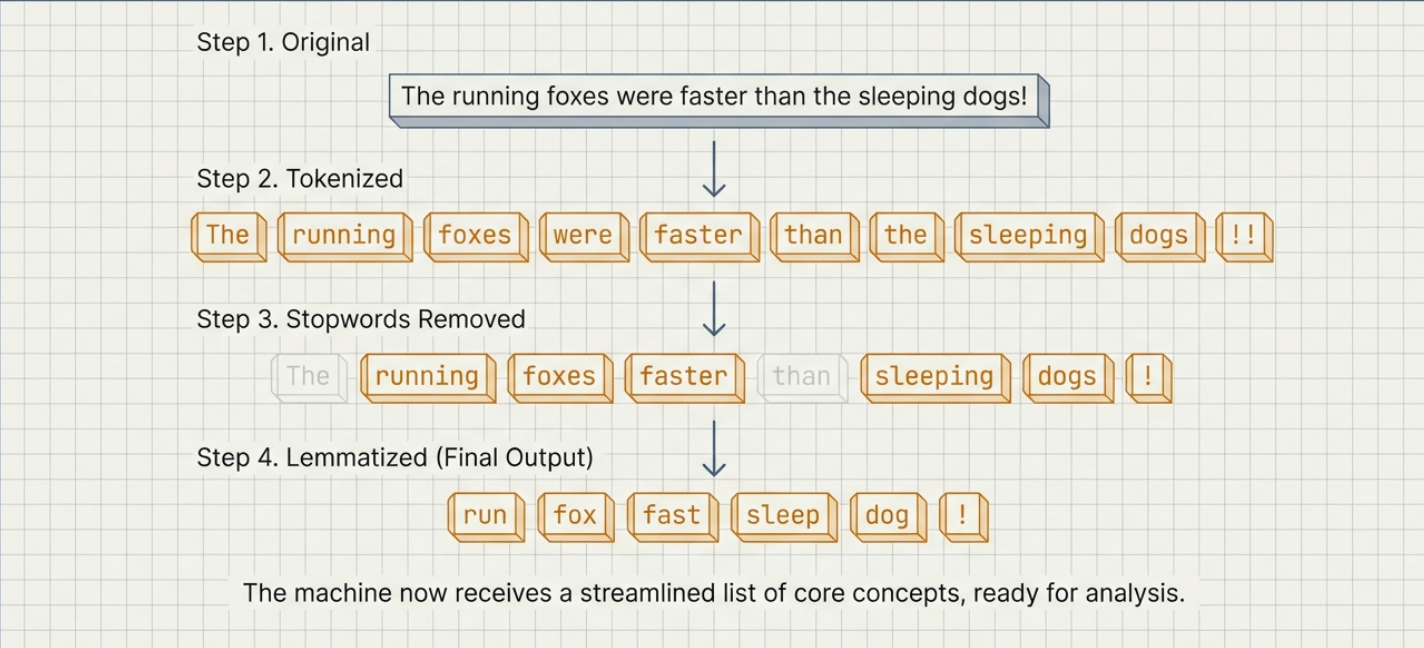

**Bag of Word**

In [ ]:
corpus = [
    'the cat sat on the mat',
    'the dog sat on the log',
    'cat and dog are friends'
]

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

In [ ]:
vectorizer = CountVectorizer()

matrix = vectorizer.fit_transform(corpus)

In [ ]:
vectorizer.get_feature_names_out() # Vocab

array(['and', 'are', 'cat', 'dog', 'friends', 'log', 'mat', 'on', 'sat',
       'the'], dtype=object)

In [ ]:
matrix.toarray()[1]

array([0, 0, 0, 1, 0, 1, 0, 1, 1, 2])

In [ ]:
corpus[1]

'the dog sat on the log'

**TF-IDF**

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
tfidfvec = TfidfVectorizer()

matrix = tfidfvec.fit_transform(corpus)

In [ ]:
import pandas as pd

In [ ]:
df = pd.DataFrame(
    matrix.toarray(),
    columns = tfidfvec.get_feature_names_out(),
    index = ['doc1','doc2','doc3']
)

In [ ]:
df

,and,are,cat,dog,friends,log,mat,on,sat,the
doc1,0.000000,0.000000,0.338470,0.000000,0.000000,0.000000,0.445047,0.33847,0.33847,0.67694
doc2,0.000000,0.000000,0.000000,0.338470,0.000000,0.445047,0.000000,0.33847,0.33847,0.67694
doc3,0.490479,0.490479,0.373022,0.373022,0.490479,0.000000,0.000000,0.00000,0.00000,0.00000


* **TF - How often the word apprear in Particular document. (ex : The present in doc 1)**
* **IDF - How Rare is the word accross all documents** (ex: rareness of THE in all docs)

**Final output- `TF*IDF`**

https://miro.com/app/board/uXjVGnq_X38=/?share_link_id=390130218359